# Reverse Game of Life — Advanced Discovery Notebook
## Architectures: RNN → BiLSTM → CRNN → Residual FCN → MLP → Attention U-Net
### With wrap padding, D4 augmentation, Optuna search, and Forward Consistency metric

## 1. Import Libraries and Utility Modules

In [1]:
import importlib
import functions
importlib.reload(functions)
from functions import *

import numpy as np
import pandas as pd
from read_from_file_df import *
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import tensorflow as tf
import matplotlib.pyplot as plt

## 2. Define Constants and Hyperparameters

In [2]:
SIZE = 5
AMOUNT_BOARDS = 1000
AMOUNT_MOVES = 100
NUM_DICT = 1
gen = 2

## 3. Load and Prepare the Reverse Game of Life Dataset

In [3]:
reverse_df_sort = load_reverse_df(SIZE, AMOUNT_BOARDS, gen)
X_train, X_val, X_test, y_train, y_val, y_test = prepare_reverse_dataset(
    reverse_df_sort, SIZE, gen, target_pixel_index=0,
    test_size=0.1, val_size=0.1, random_state=365
)
X_train_array, X_val_array, X_test_array, y_train_array, y_val_array, y_test_array = \
    to_numpy_4d(X_train, X_val, X_test, y_train, y_val, y_test, SIZE, gen)

print(f"len df: {len(reverse_df_sort)}")
print(f"len train: {len(X_train)}")
print(f"len val: {len(X_val)}")
print(f"len test: {len(X_test)}")

len df: 3637
len train: 2945
len val: 328
len test: 364


## 4. Build and Train Basic RNN Model

In [4]:
from functions import build_and_train_rnn

model, history = build_and_train_rnn(
    X_train_array, y_train_array,
    size=SIZE, gen=gen,
    rnn_units=128, dense_units=64,
    epochs=20, batch_size=512,
    validation_split=0.2
)
model.summary()

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.4372 - loss: 0.6932 - val_accuracy: 0.4211 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4661 - loss: 0.6826 - val_accuracy: 0.5297 - val_loss: 0.6946 - learning_rate: 0.0010
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5645 - loss: 0.6826 - val_accuracy: 0.5705 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5892 - loss: 0.6792 - val_accuracy: 0.5976 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6189 - loss: 0.6694 - val_accuracy: 0.6061 - val_loss: 0.6833 - learning_rate: 0.0010
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6251 - loss: 0.6649 - val_accuracy: 0.6078 - val_loss: 0.6804 - learning_rate: 0.0010
Epoch 7/20
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6309 - loss: 0.6601
Epoch 7: ReduceLROnPla

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        78,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,509 (1021.52 KB)

 Trainable params: 87,169 (340.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 174,340 (681.02 KB)

## 5. Build and Train Bidirectional Stacked LSTM (RNN v2)

In [5]:
from functions import build_and_train_rnn_v2

model_v2, history_v2 = build_and_train_rnn_v2(
    X_train_array, y_train_array,
    size=SIZE, gen=gen,
    lstm_units_1=128, lstm_units_2=64,
    dense_units_1=128, dense_units_2=64,
    dropout_rate=0.3, recurrent_dropout=0.2,
    learning_rate=0.001,
    epochs=40, batch_size=512,
    validation_split=0.2
)
model_v2.summary()

Epoch 1/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 631ms/step - accuracy: 0.5046 - loss: 0.7549 - val_accuracy: 0.6570 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 2/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5547 - loss: 0.7072 - val_accuracy: 0.5739 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 3/40
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5768 - loss: 0.6767
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5820 - loss: 0.6782 - val_accuracy: 0.6384 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 4/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6202 - loss: 0.6658 - val_accuracy: 0.6486 - val_loss: 0.6922 - learning_rate: 5.0000e-04
Epoch 5/40
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6219 - loss: 0.6613
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6208 - loss: 0.6626 - val_accuracy: 0.6

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │       157,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,043,717 (3.98 MB)

 Trainable params: 347,649 (1.33 MB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 695,300 (2.65 MB)

## 6. Run Optuna Hyperparameter Search for CRNN/ConvLSTM

In [6]:
import optuna_search
importlib.reload(optuna_search)
from optuna_search import run_optuna_search

study = run_optuna_search(
    X_train_array, y_train_array,
    X_val_array, y_val_array,
    size=SIZE, gen=gen,
    n_trials=50
)

print("\nTop 5 trials:")
for t in sorted(study.trials, key=lambda t: t.value or 0, reverse=True)[:5]:
    print(f"  Trial {t.number}: val_acc={t.value:.4f}  params={t.params}")

c:\Users\דרור\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-30 12:21:41,694] A new study created in memory with name: gol_crnn_search
  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.64939:   2%|▏         | 1/50 [00:09<07:39,  9.39s/it]

[I 2026-03-30 12:21:51,080] Trial 0 finished with value: 0.6493902206420898 and parameters: {'n_conv_layers': 1, 'conv_filters': 16, 'rnn_type': 'GRU', 'rnn_units': 32, 'dropout_rate': 0.5, 'learning_rate': 0.0009601617691025382, 'use_bidirectional': True, 'dense_units': 128, 'batch_size': 1024}. Best is trial 0 with value: 0.6493902206420898.


Best trial: 0. Best value: 0.64939:   4%|▍         | 2/50 [00:17<06:59,  8.74s/it]

[I 2026-03-30 12:21:59,373] Trial 1 finished with value: 0.6432926654815674 and parameters: {'n_conv_layers': 1, 'conv_filters': 64, 'rnn_type': 'LSTM', 'rnn_units': 64, 'dropout_rate': 0.15000000000000002, 'learning_rate': 0.00010938311157023813, 'use_bidirectional': True, 'dense_units': 32, 'batch_size': 256}. Best is trial 0 with value: 0.6493902206420898.


...

[I 2026-03-30 12:27:51,689] Trial 47 finished with value: 0.6493902206420898 and parameters: {'n_conv_layers': 1, 'conv_filters': 16, 'rnn_type': 'GRU', 'rnn_units': 64, 'dropout_rate': 0.45000000000000007, 'learning_rate': 0.0010752589627020246, 'use_bidirectional': True, 'dense_units': 32, 'batch_size': 1024}. Best is trial 12 with value: 0.6829268336296082.


Best trial: 12. Best value: 0.682927:  98%|█████████▊| 49/50 [06:16<00:07,  7.13s/it]

[I 2026-03-30 12:27:58,152] Trial 48 finished with value: 0.6493902206420898 and parameters: {'n_conv_layers': 1, 'conv_filters': 64, 'rnn_type': 'GRU', 'rnn_units': 128, 'dropout_rate': 0.45000000000000007, 'learning_rate': 0.0012108040857621227, 'use_bidirectional': False, 'dense_units': 128, 'batch_size': 1024}. Best is trial 12 with value: 0.6829268336296082.


Best trial: 12. Best value: 0.682927: 100%|██████████| 50/50 [06:23<00:00,  7.68s/it]

[I 2026-03-30 12:28:05,568] Trial 49 finished with value: 0.6432926654815674 and parameters: {'n_conv_layers': 1, 'conv_filters': 32, 'rnn_type': 'LSTM', 'rnn_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.0002936125164554935, 'use_bidirectional': True, 'dense_units': 128, 'batch_size': 256}. Best is trial 12 with value: 0.6829268336296082.

OPTUNA SEARCH COMPLETE
Best trial #12
  Val accuracy : 0.6829
  Params       : {'n_conv_layers': 1, 'conv_filters': 32, 'rnn_type': 'GRU', 'rnn_units': 128, 'dropout_rate': 0.25, 'learning_rate': 0.00035971219443254807, 'use_bidirectional': True, 'dense_units': 128, 'batch_size': 1024}

Top 5 trials:
  Trial 12: val_acc=0.6829  params={'n_conv_layers': 1, 'conv_filters': 32, 'rnn_type': 'GRU', 'rnn_units': 128, 'dropout_rate': 0.25, 'learning_rate': 0.00035971219443254807, 'use_bidirectional': True, 'dense_units': 128, 'batch_size': 1024}
  Trial 43: val_acc=0.6707  params={'n_conv_layers': 1, 'conv_filters': 32, 'rnn_type': 'GRU', 'rnn_units'

## 7. Build and Train CRNN v3 (Conv2D + BiLSTM + AdamW)

In [7]:
from functions import build_and_train_crnn_v3

model_v3, history_v3 = build_and_train_crnn_v3(
    X_train_array, y_train_array,
    size=SIZE, gen=gen,
    conv_filters=(32, 64),
    lstm_units_1=128, lstm_units_2=64,
    dense_units_1=128, dense_units_2=64,
    dropout_rate=0.3, recurrent_dropout=0.2,
    learning_rate=0.001, weight_decay=1e-4,
    epochs=50, batch_size=512,
    validation_split=0.2
)
model_v3.summary()

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 377ms/step - accuracy: 0.5176 - loss: 0.8336 - val_accuracy: 0.3328 - val_loss: 0.6948 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5422 - loss: 0.7675 - val_accuracy: 0.3328 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5300 - loss: 0.7536 - val_accuracy: 0.3328 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5172 - loss: 0.7574
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.5199 - loss: 0.7542 - val_accuracy: 0.3328 - val_loss: 0.6978 - learning_rate: 0.0010
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5415 - loss: 0.7342 - val_accuracy: 0.3328 - val_loss: 0.6985 - learning_rate: 5.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5390 - loss: 0.7176 - val_accuracy: 0

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, 1, 5, 5, 32)    │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 1, 5, 5, 32)    │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 1, 5, 5, 64)    │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 1, 5, 5, 64)    │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 1, 2, 2, 64)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 1, 256)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 1, 256)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,811,589 (6.91 MB)

 Trainable params: 603,457 (2.30 MB)

 Non-trainable params: 1,216 (4.75 KB)

 Optimizer params: 1,206,916 (4.60 MB)

## 8. Evaluate All RNN/CRNN Models on Test Set

In [8]:
# CRNN v3
X_test_crnn = X_test_array.reshape((-1, gen-1, SIZE, SIZE, 1)).astype('float32')
test_loss_v3, test_acc_v3 = model_v3.evaluate(X_test_crnn, y_test_array.astype('float32'))
print(f"Test accuracy (v3 CRNN): {test_acc_v3:.3f}")
evaluate_model(model_v3, X_test_crnn, y_test_array, SIZE, gen)

# RNN v2 (BiLSTM)
X_test_rnn_v2 = X_test_array.reshape((-1, gen-1, SIZE*SIZE)).astype('float32')
test_loss_v2, test_acc_v2 = model_v2.evaluate(X_test_rnn_v2, y_test_array.astype('float32'))
print(f"\nTest accuracy (v2 BiLSTM): {test_acc_v2:.3f}")
evaluate_model(model_v2, X_test_rnn_v2, y_test_array, SIZE, gen)

# RNN v1
X_test_rnn = X_test_array.reshape((-1, gen-1, SIZE*SIZE)).astype('float32')
test_loss, test_acc = model.evaluate(X_test_rnn, y_test_array.astype('float32'))
print(f"\nTest accuracy (v1 RNN): {test_acc:.3f}")
evaluate_model(model, X_test_rnn, y_test_array, SIZE, gen)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2592 - loss: 0.6956
Test accuracy (v3 CRNN): 0.283
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step

===== Evaluation Results =====
┌──────────────┬────────────┬────────────┐
│              │ Pred=Alive │ Pred=Dead  │
├──────────────┼────────────┼────────────┤
│ True=Alive   │        103 │          0 │
│ True=Dead    │        261 │          0 │
└──────────────┴────────────┴────────────┘

--- Performance Metrics ---
Accuracy    : 0.283
Precision   : 0.283
Recall      : 1.000
F1-score    : 0.441
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7362 - loss: 0.6913  

Test accuracy (v2 BiLSTM): 0.717
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step

===== Evaluation Results =====
┌──────────────┬────────────┬────────────┐
│              │ Pred=Alive │ Pred=Dead  │
├──────────────┼────────────┼────────────┤
│ True=Alive   │         12 │         91 │
│ True=Dead    │         12 │        249 │
└──────────────┴────────────┴────────────┘

--- Performance M

## 9. Diagnostic: Data Shapes, Class Balance, and Baseline Performance

In [9]:
print(f"SIZE={SIZE}, gen={gen}, AMOUNT_BOARDS={AMOUNT_BOARDS}")
print(f"X_train_array shape: {X_train_array.shape}")
print(f"X_val_array shape:   {X_val_array.shape}")
print(f"X_test_array shape:  {X_test_array.shape}")
print(f"y_train_array shape: {y_train_array.shape}")
print(f"reverse_df_sort shape: {reverse_df_sort.shape}")
print(f"\nClass balance (y_train): {np.mean(y_train_array):.3f}")

X_test_rnn = X_test_array.reshape((-1, gen-1, SIZE*SIZE)).astype('float32')
test_loss, test_acc = model.evaluate(X_test_rnn, y_test_array.astype('float32'), verbose=0)
print(f"\nCurrent RNN (v1) test accuracy: {test_acc:.4f}")

SIZE=5, gen=2, AMOUNT_BOARDS=1000
X_train_array shape: (2945, 5, 5, 1)
X_val_array shape:   (328, 5, 5, 1)
X_test_array shape:  (364, 5, 5, 1)
y_train_array shape: (2945, 1)
reverse_df_sort shape: (3637, 50)

Class balance (y_train): 0.324

Current RNN (v1) test accuracy: 0.6648


## 10. Iteration 1: Residual FCN with Wrap Padding + Full-Board Prediction
**Key insights:**
- gen=2 → timesteps=1 → RNN is useless, this is a SPATIAL problem
- GoL board is TOROIDAL → need wrap padding for CNN
- Class imbalance (~20% alive) → current 0.80 ≈ "predict all dead"
- Predict ALL pixels → much more gradient signal

In [10]:
tf.keras.backend.clear_session()

# --- 1) Extract full-board targets ---
amount_feat = (gen - 1) * SIZE * SIZE
target_cols = [f'Col_{amount_feat + i}' for i in range(SIZE * SIZE)]

y_train_board = reverse_df_sort.loc[X_train.index, target_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')
y_val_board   = reverse_df_sort.loc[X_val.index, target_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')
y_test_board  = reverse_df_sort.loc[X_test.index, target_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')

# --- 2) Wrap-pad inputs for toroidal topology ---
PAD = 3
X_train_wp = np.pad(X_train_array, ((0,0),(PAD,PAD),(PAD,PAD),(0,0)), mode='wrap').astype('float32')
X_val_wp   = np.pad(X_val_array,   ((0,0),(PAD,PAD),(PAD,PAD),(0,0)), mode='wrap').astype('float32')
X_test_wp  = np.pad(X_test_array,  ((0,0),(PAD,PAD),(PAD,PAD),(0,0)), mode='wrap').astype('float32')

print(f"Input:  {X_train_wp.shape}")
print(f"Target: {y_train_board.shape}")
print(f"Target alive fraction: {np.mean(y_train_board):.3f}")

# --- 3) Compute class weight ---
frac_alive = float(np.mean(y_train_board))
w1 = (1 - frac_alive) / frac_alive
print(f"Alive weight: {w1:.2f}")

# --- 4) Build Residual FCN ---
padded_size = SIZE + 2 * PAD
inputs = tf.keras.Input(shape=(padded_size, padded_size, 1))

x = tf.keras.layers.Conv2D(64, 3, padding='same')(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

def res_block(x, filters):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

x = res_block(x, 64)
x = res_block(x, 128)
x = res_block(x, 128)
x = res_block(x, 64)

x = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(x)
x = tf.keras.layers.Cropping2D(cropping=((PAD, PAD), (PAD, PAD)))(x)

model_iter1 = tf.keras.Model(inputs, x, name='ResFCN_WrapPad')

def weighted_bce(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    weights = y_true * w1 + (1 - y_true) * 1.0
    weights = tf.squeeze(weights, axis=-1)
    return bce * weights

model_iter1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=weighted_bce, metrics=['accuracy']
)
model_iter1.summary()

# --- 5) Train ---
history_iter1 = model_iter1.fit(
    X_train_wp, y_train_board,
    validation_data=(X_val_wp, y_val_board),
    epochs=60, batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ],
    verbose=2
)

# --- 6) Evaluate ---
best_val_acc = max(history_iter1.history['val_accuracy'])
print(f"\n{'='*50}")
print(f"Best val accuracy (all pixels): {best_val_acc:.4f}")

y_pred_board = model_iter1.predict(X_test_wp, verbose=0)
all_pred = (y_pred_board > 0.5).astype(int)
all_true = y_test_board.astype(int)
overall_acc = np.mean(all_pred == all_true)
print(f"Test accuracy (all pixels): {overall_acc:.4f}")

p0_pred = (y_pred_board[:, 0, 0, 0] > 0.5).astype(int)
p0_true = y_test_board[:, 0, 0, 0].astype(int)
p0_f1 = f1_score(p0_true, p0_pred)
p0_prec = precision_score(p0_true, p0_pred, zero_division=0)
p0_recall = recall_score(p0_true, p0_pred, zero_division=0)
print(f"Pixel-0 acc={np.mean(p0_pred==p0_true):.4f}  F1={p0_f1:.4f}  Prec={p0_prec:.4f}  Recall={p0_recall:.4f}")

alive_mask = all_true.flatten() == 1
dead_mask = all_true.flatten() == 0
print(f"ALIVE acc: {np.mean(all_pred.flatten()[alive_mask] == 1):.4f}")
print(f"DEAD acc:  {np.mean(all_pred.flatten()[dead_mask] == 0):.4f}")
print(f"{'='*50}")

Input:  (2945, 11, 11, 1)
Target: (2945, 5, 5, 1)
Target alive fraction: 0.332
Alive weight: 2.01


Model: "ResFCN_WrapPad"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 11, 11, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 11, 11,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 11, 11,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 11, 11,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 11, 11,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 11,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 11, 11,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 11, 11,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 11,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 11, 11,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 11, 11,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 11, 11,    │     73,856 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 11,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 11, 11,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 11, 11,    │    147,584 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 11, 11,    │      8,320 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 11, 11,    │        512 │ conv2d_5[0][0]  

 Total params: 722,561 (2.76 MB)

 Trainable params: 720,513 (2.75 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/60
12/12 - 22s - 2s/step - accuracy: 0.6215 - loss: 0.9147 - val_accuracy: 0.5026 - val_loss: 0.9223 - learning_rate: 0.0010
Epoch 2/60
12/12 - 14s - 1s/step - accuracy: 0.7091 - loss: 0.7542 - val_accuracy: 0.3446 - val_loss: 0.9374 - learning_rate: 0.0010
Epoch 3/60
12/12 - 13s - 1s/step - accuracy: 0.7561 - loss: 0.6745 - val_accuracy: 0.3343 - val_loss: 0.9907 - learning_rate: 0.0010
Epoch 4/60

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
12/12 - 20s - 2s/step - accuracy: 0.7822 - loss: 0.6067 - val_accuracy: 0.3343 - val_loss: 1.0754 - learning_rate: 0.0010
Epoch 5/60
12/12 - 14s - 1s/step - accuracy: 0.8297 - loss: 0.5195 - val_accuracy: 0.3343 - val_loss: 1.1199 - learning_rate: 5.0000e-04
Epoch 6/60
12/12 - 15s - 1s/step - accuracy: 0.8544 - loss: 0.4609 - val_accuracy: 0.3343 - val_loss: 1.2302 - learning_rate: 5.0000e-04
Epoch 7/60

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
12/12 - 20s - 2s/step - accur

## 11. Iteration 2: Multi-Output MLP with Engineered GoL Features

In [11]:
tf.keras.backend.clear_session()

# --- 1) Prepare full-board targets (flat) ---
amount_feat = (gen - 1) * SIZE * SIZE
target_cols = [f'Col_{amount_feat + i}' for i in range(SIZE * SIZE)]
y_train_flat = reverse_df_sort.loc[X_train.index, target_cols].to_numpy().reshape(-1, SIZE*SIZE).astype('float32')
y_val_flat   = reverse_df_sort.loc[X_val.index, target_cols].to_numpy().reshape(-1, SIZE*SIZE).astype('float32')
y_test_flat  = reverse_df_sort.loc[X_test.index, target_cols].to_numpy().reshape(-1, SIZE*SIZE).astype('float32')

# --- 2) Engineer GoL features ---
def gol_features(boards_4d, size):
    b = boards_4d[:, :, :, 0].astype('float32')
    n = b.shape[0]
    padded = np.pad(b, ((0,0),(1,1),(1,1)), mode='wrap')
    neigh = np.zeros_like(b)
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            neigh += padded[:, 1+di:size+1+di, 1+dj:size+1+dj]
    return np.concatenate([b.reshape(n,-1), neigh.reshape(n,-1) / 8.0], axis=1)

X_tr = gol_features(X_train_array, SIZE)
X_va = gol_features(X_val_array, SIZE)
X_te = gol_features(X_test_array, SIZE)
print(f"Feature shape: {X_tr.shape}, Target shape: {y_train_flat.shape}")

# --- 3) Build MLP ---
model_mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr.shape[1],)),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(SIZE*SIZE, activation='sigmoid'),
], name='MLP_GoLFeatures')

model_mlp.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='binary_crossentropy', metrics=['accuracy']
)
model_mlp.summary()

# --- 4) Train ---
hist_mlp = model_mlp.fit(
    X_tr, y_train_flat,
    validation_data=(X_va, y_val_flat),
    epochs=100, batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ],
    verbose=2
)

# --- 5) Evaluate ---
best_val = max(hist_mlp.history['val_accuracy'])
print(f"\n{'='*50}")
print(f"Best val accuracy (all pixels): {best_val:.4f}")

y_pred = model_mlp.predict(X_te, verbose=0)
pred = (y_pred > 0.5).astype(int)
true = y_test_flat.astype(int)
overall = np.mean(pred == true)
print(f"Test accuracy (all pixels): {overall:.4f}")

p0_pred = pred[:, 0]; p0_true = true[:, 0]
print(f"Pixel-0 acc={np.mean(p0_pred==p0_true):.4f}  F1={f1_score(p0_true, p0_pred):.4f}")

alive_mask = true.flatten() == 1; dead_mask = true.flatten() == 0
print(f"ALIVE acc: {np.mean(pred.flatten()[alive_mask] == 1):.4f}")
print(f"DEAD acc:  {np.mean(pred.flatten()[dead_mask] == 0):.4f}")

if best_val >= 0.90:
    print(">>> TARGET 0.90 REACHED! <<<")
    model_mlp.save('models/MLP_GoL_best.keras')
print(f"{'='*50}")

Feature shape: (2945, 50), Target shape: (2945, 25)


Model: "MLP_GoLFeatures"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 721,945 (2.75 MB)

 Trainable params: 718,361 (2.74 MB)

 Non-trainable params: 3,584 (14.00 KB)

Epoch 1/100
3/3 - 5s - 2s/step - accuracy: 0.0455 - loss: 0.8876 - val_accuracy: 0.0610 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 2/100
3/3 - 0s - 99ms/step - accuracy: 0.0686 - loss: 0.7988 - val_accuracy: 0.0579 - val_loss: 0.6882 - learning_rate: 0.0010
Epoch 3/100
3/3 - 0s - 147ms/step - accuracy: 0.0676 - loss: 0.7647 - val_accuracy: 0.0396 - val_loss: 0.6845 - learning_rate: 0.0010
Epoch 4/100
3/3 - 0s - 125ms/step - accuracy: 0.0649 - loss: 0.7353 - val_accuracy: 0.0213 - val_loss: 0.6830 - learning_rate: 0.0010
Epoch 5/100
3/3 - 1s - 169ms/step - accuracy: 0.0795 - loss: 0.7137 - val_accuracy: 0.0183 - val_loss: 0.6812 - learning_rate: 0.0010
Epoch 6/100
3/3 - 1s - 210ms/step - accuracy: 0.0696 - loss: 0.6960 - val_accuracy: 0.0274 - val_loss: 0.6789 - learning_rate: 0.0010
Epoch 7/100
3/3 - 0s - 113ms/step - accuracy: 0.0727 - loss: 0.6864 - val_accuracy: 0.0396 - val_loss: 0.6759 - learning_rate: 0.0010
Epoch 8/100
3/3 - 0s - 105ms/step - accuracy: 0.0812 - loss: 0.674

## 12. Overfitting Diagnostic: Training vs Validation Curves

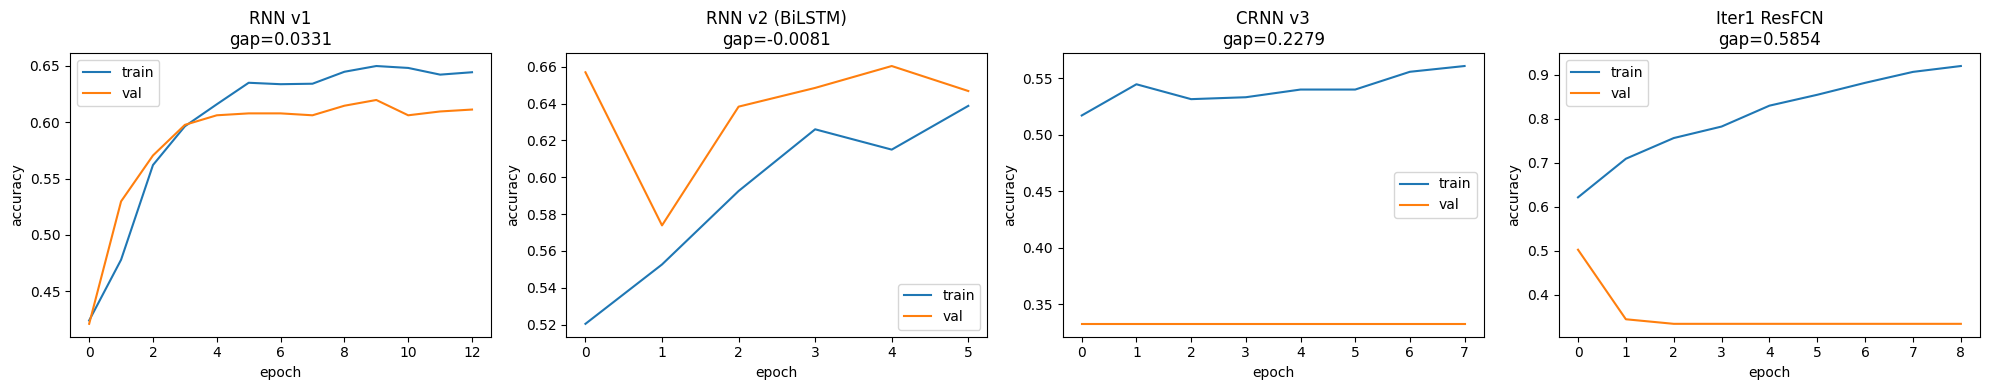

RNN v1                train=0.6443  val=0.6112  gap=0.0331
RNN v2 (BiLSTM)       train=0.6388  val=0.6469  gap=-0.0081
CRNN v3               train=0.5607  val=0.3328  gap=0.2279
Iter1 ResFCN          train=0.9197  val=0.3343  gap=0.5854


In [12]:
histories = {
    'RNN v1': history,
    'RNN v2 (BiLSTM)': history_v2,
    'CRNN v3': history_v3,
    'Iter1 ResFCN': history_iter1,
}

fig, axes = plt.subplots(1, len(histories), figsize=(5*len(histories), 4))
for ax, (name, h) in zip(axes, histories.items()):
    train_acc = h.history.get('accuracy', [])
    val_acc   = h.history.get('val_accuracy', [])
    ax.plot(train_acc, label='train')
    ax.plot(val_acc, label='val')
    gap = train_acc[-1] - val_acc[-1] if train_acc and val_acc else 0
    ax.set_title(f'{name}\ngap={gap:.4f}')
    ax.set_xlabel('epoch'); ax.set_ylabel('accuracy')
    ax.legend()
plt.tight_layout()
plt.show()

for name, h in histories.items():
    t = h.history.get('accuracy', [0])[-1]
    v = h.history.get('val_accuracy', [0])[-1]
    print(f"{name:20s}  train={t:.4f}  val={v:.4f}  gap={t-v:.4f}")

## 13. Iteration 3: D4 Augmentation + Lighter Residual FCN
Fix overfitting: 8× D4 augmentation, lighter model (32→64 filters), SpatialDropout2D, L2 regularization, label smoothing.

In [13]:
tf.keras.backend.clear_session()

# --- 1) Full-board targets (2D) ---
amount_feat = (gen - 1) * SIZE * SIZE
target_cols = [f'Col_{amount_feat + i}' for i in range(SIZE * SIZE)]
y_train_board = reverse_df_sort.loc[X_train.index, target_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')
y_val_board   = reverse_df_sort.loc[X_val.index, target_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')
y_test_board  = reverse_df_sort.loc[X_test.index, target_cols].to_numpy().reshape(-1, SIZE, SIZE, 1).astype('float32')

# --- 2) Wrap-pad inputs ---
PAD = 2
X_train_wp = np.pad(X_train_array, ((0,0),(PAD,PAD),(PAD,PAD),(0,0)), mode='wrap').astype('float32')
X_val_wp   = np.pad(X_val_array,   ((0,0),(PAD,PAD),(PAD,PAD),(0,0)), mode='wrap').astype('float32')
X_test_wp  = np.pad(X_test_array,  ((0,0),(PAD,PAD),(PAD,PAD),(0,0)), mode='wrap').astype('float32')

# --- 3) D4 augmentation ---
def augment_d4_with_wrap(X_raw, y, pad):
    Xr, yr = [X_raw], [y]
    for k in range(1, 4):
        Xr.append(np.rot90(X_raw, k, axes=(1, 2)))
        yr.append(np.rot90(y, k, axes=(1, 2)))
    X_flip = X_raw[:, :, ::-1, :]; y_flip = y[:, :, ::-1, :]
    Xr.append(X_flip); yr.append(y_flip)
    for k in range(1, 4):
        Xr.append(np.rot90(X_flip, k, axes=(1, 2)))
        yr.append(np.rot90(y_flip, k, axes=(1, 2)))
    X_all = np.concatenate(Xr); y_all = np.concatenate(yr)
    return np.pad(X_all, ((0,0),(pad,pad),(pad,pad),(0,0)), mode='wrap').astype('float32'), y_all

X_train_aug, y_train_aug = augment_d4_with_wrap(X_train_array, y_train_board, PAD)
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_train_aug))
X_train_aug, y_train_aug = X_train_aug[idx], y_train_aug[idx]

print(f"Original: {X_train_wp.shape[0]}, Augmented: {X_train_aug.shape[0]} (8× D4)")

# --- 4) Build lighter Residual FCN ---
padded_size = SIZE + 2 * PAD
inputs = tf.keras.Input(shape=(padded_size, padded_size, 1))

def res_block_light(x, filters):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, padding='same',
                                          kernel_regularizer=tf.keras.regularizers.l2(1e-4))(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same',
                                kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same',
                                kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x

x = tf.keras.layers.Conv2D(32, 3, padding='same',
                            kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = res_block_light(x, 32)
x = res_block_light(x, 64)
x = tf.keras.layers.SpatialDropout2D(0.2)(x)
x = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(x)
x = tf.keras.layers.Cropping2D(cropping=((PAD, PAD), (PAD, PAD)))(x)

model_iter3 = tf.keras.Model(inputs, x, name='ResFCN_Light_D4')
model_iter3.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=5e-4),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
print(f"Parameters: {model_iter3.count_params():,}")
model_iter3.summary()

# --- 5) Train ---
history_iter3 = model_iter3.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val_wp, y_val_board),
    epochs=80, batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ],
    verbose=2
)

# --- 6) Evaluate ---
best_train = max(history_iter3.history['accuracy'])
best_val = max(history_iter3.history['val_accuracy'])
print(f"\n{'='*50}")
print(f"Iter3: Best train={best_train:.4f}  val={best_val:.4f}  gap={best_train-best_val:.4f}")

y_pred_board = model_iter3.predict(X_test_wp, verbose=0)
all_pred = (y_pred_board > 0.5).astype(int)
all_true = y_test_board.astype(int)
print(f"Test accuracy: {np.mean(all_pred == all_true):.4f}")

alive_mask = all_true.flatten() == 1; dead_mask = all_true.flatten() == 0
print(f"ALIVE acc: {np.mean(all_pred.flatten()[alive_mask] == 1):.4f}")
print(f"DEAD acc:  {np.mean(all_pred.flatten()[dead_mask] == 0):.4f}")

if best_val >= 0.90:
    print(">>> TARGET 0.90 REACHED! <<<")
    model_iter3.save('models/ResFCN_D4_best.keras')
else:
    print(f">>> Gap to target: {0.90 - best_val:.4f} <<<")
print(f"{'='*50}")

Original: 2945, Augmented: 23560 (8× D4)
Parameters: 77,569


Model: "ResFCN_Light_D4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9, 9, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 9, 9, 32)  │        320 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 9, 9, 32)  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 9, 9, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 9, 9, 32)  │      9,248 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 32)  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 9, 9, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 9, 9, 32)  │          0 │ activation_1[0][… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 9, 9, 32)  │      9,248 │ spatial_dropout2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 32)  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 9, 32)  │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 9, 9, 32)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 9, 9, 64)  │     18,496 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 64)  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 9, 9, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 9, 9, 64)  │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 9, 9, 64)  │     36,928 │ spatial_dropout2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 9, 9, 64)  │      2,112 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 64)  │        256 │ conv2d_5[0][0]  

 Total params: 77,569 (303.00 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/80
93/93 - 23s - 247ms/step - accuracy: 0.6928 - loss: 0.6327 - val_accuracy: 0.5305 - val_loss: 0.7087 - learning_rate: 0.0010
Epoch 2/80
93/93 - 14s - 147ms/step - accuracy: 0.7217 - loss: 0.5877 - val_accuracy: 0.4860 - val_loss: 0.7311 - learning_rate: 0.0010
Epoch 3/80
93/93 - 16s - 169ms/step - accuracy: 0.7322 - loss: 0.5719 - val_accuracy: 0.5394 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 4/80
93/93 - 13s - 137ms/step - accuracy: 0.7404 - loss: 0.5607 - val_accuracy: 0.6993 - val_loss: 0.6178 - learning_rate: 0.0010
Epoch 5/80
93/93 - 13s - 140ms/step - accuracy: 0.7456 - loss: 0.5540 - val_accuracy: 0.7399 - val_loss: 0.5634 - learning_rate: 0.0010
Epoch 6/80
93/93 - 13s - 141ms/step - accuracy: 0.7517 - loss: 0.5454 - val_accuracy: 0.7563 - val_loss: 0.5501 - learning_rate: 0.0010
Epoch 7/80
93/93 - 12s - 133ms/step - accuracy: 0.7533 - loss: 0.5431 - val_accuracy: 0.7651 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 8/80
93/93 - 13s - 135ms/step - accuracy: 

## 14. Advanced: Attention Residual U-Net (10×10) with Forward Consistency
Uses `advanced_discovery_model.py` which includes:
- **Attention Residual U-Net** with wrap padding for toroidal topology
- **Forward Consistency** metric: steps predicted T-1 forward via GoL rules and compares to input T
- D4 augmentation, AdamW + label smoothing

In [14]:
import advanced_discovery_model as adm
importlib.reload(adm)

results = adm.train_and_evaluate(
    size=10,
    amount_boards=10000,
    gen=2,
    base_filters=48,
    depth=3,
    pad=2,
    dropout_rate=0.2,
    learning_rate=1e-3,
    weight_decay=5e-4,
    batch_size=256,
    epochs=80,
    use_augmentation=True,
)

print(f"\n{'='*60}")
print("COMPARISON: Standard Accuracy vs Forward Consistency")
print(f"{'='*60}")
print(f"  Pixel Accuracy (test)      : {results['test_accuracy']:.4f}")
print(f"  Forward Consistency (test)  : {results['forward_consistency_test']:.4f}")
print(f"  Forward Consistency (val)   : {results['forward_consistency_val']:.4f}")
print(f"  Best Val Accuracy           : {results['best_val_accuracy']:.4f}")
print(f"  ALIVE cell accuracy         : {results['alive_accuracy']:.4f}")
print(f"  DEAD cell accuracy          : {results['dead_accuracy']:.4f}")
print(f"{'='*60}")

Data loaded — train: 327960, val: 36441, test: 40490


MemoryError: Unable to allocate 1001. MiB for an array with shape (2623680, 10, 10, 1) and data type float32

## Visualization: Sample Predictions from Best Model

In [15]:
adm_model = results['model']
adm_data = adm.load_data_full_board(SIZE, AMOUNT_BOARDS, gen)
X_test_adm = adm_data['X_test']
y_test_adm = adm_data['y_test']
y_pred_adm = adm_model.predict(X_test_adm, verbose=0)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
sample_idx = np.random.choice(len(X_test_adm), 5, replace=False)

for col, si in enumerate(sample_idx):
    axes[0, col].imshow(X_test_adm[si, :, :, 0], cmap='binary', vmin=0, vmax=1)
    axes[0, col].set_title('Input (T)'); axes[0, col].axis('off')
    axes[1, col].imshow(y_test_adm[si, :, :, 0], cmap='binary', vmin=0, vmax=1)
    axes[1, col].set_title('Ground Truth (T-1)'); axes[1, col].axis('off')
    axes[2, col].imshow((y_pred_adm[si, :, :, 0] > 0.5).astype(float), cmap='binary', vmin=0, vmax=1)
    axes[2, col].set_title('Predicted (T-1)'); axes[2, col].axis('off')

plt.suptitle('Attention ResUNet: Sample Predictions', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'results' is not defined